In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']


test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_name = emotion_dataset['train'].features['label'].names

In [4]:
for i in train_label:
  print(label_name[i])

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

In [5]:
df_train = pd.DataFrame({
    'text' : train_text,
    'label' : [label_name[i] for i in train_label]
})


df_test = pd.DataFrame({
    'text' : test_text,
    'label' :[label_name[i] for i in test_label]
})

In [6]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
df_train.isnull().sum()

,0
text,0
label,0


In [8]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


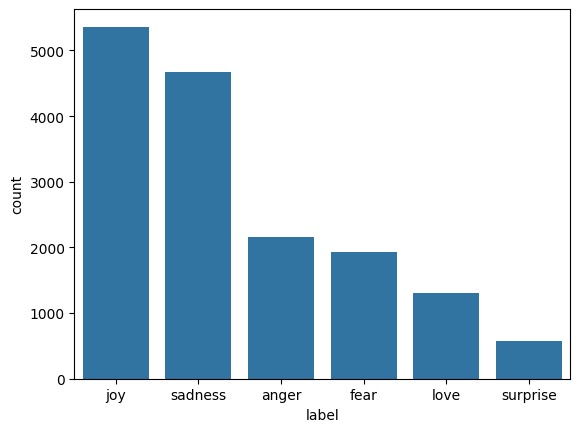

In [9]:
sns.countplot(x = 'label',data = df_train,order = df_train['label'].value_counts().index)
plt.show()

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words = max_words,oov_token = '<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen = 50,padding = 'post',truncating = 'post')
padded_test_sequence = pad_sequences(test_sequence,maxlen = 50,padding = 'post',truncating = 'post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)


num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


In [11]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels

)

class_weight_dict = dict(enumerate(class_weights))

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor = 'val_loss',
              patience = 3,
              restore_best_weights = True
                               )

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding,Dense,Dropout,LSTM,GRU

#RNN


In [ ]:


model = Sequential([
    Embedding(input_dim = max_words,output_dim = 128,input_length = 50, mask_zero = True),
    SimpleRNN(units = 128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(units = num_classes,activation = 'softmax')
])

model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])
rnn_model = model

In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence,test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

In [ ]:
rnn_loss,rnn_accuracy = model.evaluate(padded_test_sequence,test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

#LSTM


In [ ]:
LSTM_model = Sequential([
    Embedding(input_dim = max_words,output_dim = 128,input_length = 50, mask_zero = True),
    LSTM(units = 128,return_sequences=True),
    Dropout(0.5),
    LSTM(units = 64),
    Dropout(0.5),
    Dense(units = num_classes,activation = 'softmax')
])

LSTM_model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])


LSTM_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence,test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

LSTM_loss,LSTM_accuracy = LSTM_model.evaluate(padded_test_sequence,test_labels)
print(f"LSTM Loss: {LSTM_loss}")
print(f"LSTM Accuracy: {LSTM_accuracy}")

In [ ]:
GRU_model = Sequential([
    Embedding(input_dim = max_words,output_dim = 128,input_length = 50, mask_zero = True),
    GRU(units = 128,return_sequences=True),
    Dropout(0.5),
    GRU(units = 64),
    Dropout(0.5),
    Dense(units = num_classes,activation = 'softmax')
])

GRU_model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])


GRU_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence,test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

GRU_loss,GRU_accuracy = GRU_model.evaluate(padded_test_sequence,test_labels)
print(f"GRU Loss: {GRU_loss}")
print(f"GRU Accuracy: {GRU_accuracy}")

In [ ]:
result_df = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Loss':[rnn_loss,LSTM_loss,GRU_loss],
    'Accuracy':[rnn_accuracy,LSTM_accuracy,GRU_accuracy]
}).sort_values(by= 'Accuracy',ascending = False)

result_df

#BIGRU

In [15]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, mask_zero = True),
    Bidirectional(GRU(128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes,activation='softmax')
])


BiGRU.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

BiGRU.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence,test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 171s 327ms/step - accuracy: 0.6526 - loss: 0.9270 - val_accuracy: 0.8965 - val_loss: 0.2968
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 212s 348ms/step - accuracy: 0.9298 - loss: 0.1928 - val_accuracy: 0.9185 - val_loss: 0.2241
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 331ms/step - accuracy: 0.9549 - loss: 0.1166 - val_accuracy: 0.9190 - val_loss: 0.2540
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 330ms/step - accuracy: 0.9694 - loss: 0.0791 - val_accuracy: 0.9290 - val_loss: 0.2261
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 257s 515ms/step - accuracy: 0.9728 - loss: 0.0729 - val_accuracy: 0.9210 - val_loss: 0.2969


In [17]:
BiGRU_loss,BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence , test_labels)
print(f"BiGRU LOSS: {BiGRU_loss}")
print(f"BiGRU ACCURACY: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.9185 - loss: 0.2241
BiGRU LOSS: 0.2241203337907791
BiGRU ACCURACY: 0.9185000061988831


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step


<Axes: >

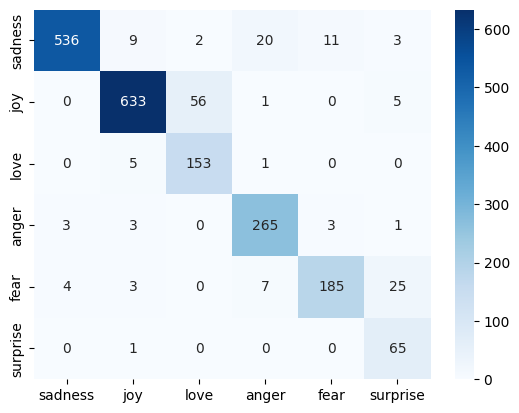

In [18]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_name, yticklabels=label_name)


In [20]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences,maxlen = 50 , padding ='post',truncating = 'post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences),axis = 1)

for i in range(len(sample_texts)):
  print(f"Text : {sample_texts[i]}\nPredicted Emotion: {label_name[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Text : I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text : I feel so alone and hopeless today.
Predicted Emotion: sadness
Text : I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text : I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text : I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [26]:
import os
import pickle

model_dir = "Artifacts"
os.makedirs(model_dir,exist_ok = True)

BiGRU.save(os.path.join(model_dir,'BiGRU_Model.keras'))

with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer,file)